# **ACCEPTANCE-REJECTION METHOD (GENERATING DRAWINGS FROM OTHER DISTRIBUTIONS)**
The following method generates F-distributed drawings $x_i$, given that we know how to generate G-distributed drawings  $y_i$ for a distribution function G with CG' $\geq$ F' for some C > 0.
    - A common example is drawing the Normal distribution (F) with the exponential distribution (G).

### **Lemma 56 (Acceptance-Rejection Sampling)**

Let $F$(our target) denote a distribution function.

Given drawings $(u_j, y_j), j = 1, 2, \ldots$, from a random variable $(U, Y)$, where $U$ and $Y$ are independent random variables and $U$ has uniform distribution on $(0, 1)$ and $Y$ has distribution function $G$. Let $f(x) := \frac{\partial}{\partial x} F(x)$ and $g(y) := \frac{\partial}{\partial y} G(y)$ denote the corresponding densities and assume that

$$
\forall x \in \mathbb{R} : f(x) \leq 1.5 \cdot g(x)
$$.

Then the sequence

$$
x_i := y_{k_i}, \quad i = 1, 2, \ldots
$$

is a drawing of a random variable $X$ with distribution $F$, where

$k_0 := 0$

$$
k_i := \min \left\{ j > k_{i-1} \mid u_j \leq \frac{f(y_j)}{1.5 \cdot g(y_j)} \right\}
$$

That is, $j = k_1, k_2, k_3, \ldots$ are the successive indices for which $u_j \leq \frac{f(y_j)}{1.5 \cdot g(y_j)}$.

<p align="center">
<img src="image-21.png" alt="Acceptance-Rejection Sampling" width="500"/>
</p>


> To simulate values from a target distribution **F** using samples from an easier distribution **G**, the acceptance-rejection method generates pairs $(u, y)$, where $u$ is uniformly distributed on $(0,1)$ and $y$ follows $G$. We accept a sample $y$ if the uniform value satisfies $u \leq f(y)/(C \cdot g(y))$, where $f$ and $g$ are the densities of $F$ and $G$, respectively, and $C$ is a constant such that $f(x) \leq C \cdot g(x)$ for all $x$. If the condition is not satisfied, we reject the pair and draw a new one. Accepted values will follow the target distribution $F$.

<p align="center">
<img src="image-22.png" alt="Acceptance-Rejection Sampling" width="500"/>
</p>

---
**Proof:**  
We first note that  
$$
P\left(U \leq \frac{f(Y)}{C \cdot g(Y)}\right) = \frac{1}{C}, \quad \text{recall the subset } \left\{ \omega \in \Omega \; \middle| \; U(\omega) \leq \frac{f(Y(\omega))}{C \cdot g(Y(\omega))} \right\}
$$.  
This follows since:

$$
P(U \leq \frac{f(Y)}{C g(Y)} \mid Y = y) = P(U \leq \frac{f(y)}{C g(y)}) = \frac{f(y)}{C g(y)}
$$

and thus:

$$
P(U \leq \frac{f(Y)}{C g(Y)}) = \int_{-\infty}^{\infty} P(U \leq \frac{f(Y)}{C g(Y)} \mid Y = y) \cdot g(y) \, dy = \int_{-\infty}^{\infty}  \frac{f(y)}{C g(y)} g(y) dy = \int_{-\infty}^{\infty} f(y) \cdot \frac{1}{C} \, dy = \frac{1}{C}
$$

**Remark:**  
Note that $\frac{f(y)}{C g(y)}$ gives the probability to accept a value of $y$.

- So, we would like to make the C as small as possible, but don't forget that multiplied by g(x) it needs to be greater or equal to f(x).

<p align="center">
<img src="image-23.png" alt="Acceptance-Rejection Sampling" width="500"/>
</p>

--- 
**PROVE THAT THIS SEQUENCE REALLY GENERATES SAMPLES WITH DISTRIBUTION FUNCTION F**

Using $P(A|B) = \frac{A \cap B}{P(B)}$ with A = $\{ Y \leq x\}$ `(interest event, what we want to have the prob F(x))` and B = $\{U \leq \frac{f(Y)}{Cg(Y)}\}$ `(The event in which a sample *y* was accepted)`we get:
$$
P(x \leq x) = P(Y \leq x | U \leq \frac{f(Y)}{Cg(Y)}) = \frac{P(\{Y \leq x\}) \cap \{U \leq \frac{f(Y)}{Cg(Y)}\}}{P(U \leq \frac{f(Y)}{Cg(Y)})}
$$

where:
- ${P(U \leq \frac{f(Y)}{Cg(Y)})} = \frac{1}{C}$

$$
= C \cdot P(\{Y \leq x\}) \cap \{U \leq \frac{f(Y)}{Cg(Y)}\}
$$

$$
= C \cdot \int_{\infty}^{\infty} P(\{Y \leq x\}) \cap \{U \leq \frac{f(Y)}{Cg(Y)}\} \cdot g(z) dz
$$

$$
= C \cdot \int_{\infty}^{x} \frac{f(z)}{Cg(z)} \cdot g(z) dz = \int_{-\infty}^{x} f(z) dz = F(x)
$$


That is, X has distribution function F. 


---
## 🔨 Tip (Acceptance-Rejection):

When using the method, it should be avoided that the densities $f$ and $g$ depend on some model parameter, say $\theta$, which is later varied.

In that case, the generated sequence is likely *discontinuous* in that parameter, even if the densities are smooth in the parameter.

For example, assume that $f = f_{\theta}$ depends on an additional model parameter $\theta$, and that for some $i$ we have:

- $u_i \leq \frac{f_{\theta_0}(y_i)}{C g(y_i)}$
- and $u_i > \frac{f_{\theta_0 + \varepsilon}(y_i)}{C g(y_i)}$

In that case, $y_i$ would be accepted for $\theta = \theta_0$, but rejected for $\theta = \theta_0 + \varepsilon$.  
In that case, a point is removed from the series.

**If the sequence is used to sample multi-dimensional random variables**, the result may be similar in effect as changing the whole sequence. Calculating a finite difference with respect to $\theta$ may result in very large Monte Carlo errors (poor Monte Carlo convergence).

> When using acceptance-rejection, don’t let your target density $f_\theta$ depend on a parameter $\theta$ that you will vary later.
> Even small changes in $\theta$ can cause points to be accepted or rejected differently, making the output discontinuos in $\theta$. 
> Instead, sample from a fixed ditributed (e.g. standard normal), and rescale outside the method. This ensures smooth, stable behavior when $\theta$ changes. 

--- 
## **COMBINING ACCEPTANCE-REJECTION METHOD SAMPLING WITH AN INVERSE DISTRIBUTION FUNCTION**


Assume that, in addition, we know $ G^{-1} $ in closed form (or have a sufficiently accurate approximation).  
In that case, we may generate $ y_j $ from a uniform sequence $ v_j $ via

$$
y_j = G^{-1}(v_j)
$$

The algorithm then is:

- ▶Given a sequence $ (u_j, v_j) $ sampling a random variable $ (U, V) \sim \text{uniform on } [0, 1]^2 $
- ▶Generate the sequence $ x_j = G^{-1}(v_{k_j}) $ by selecting only those elements for which

$$
u_j \leq \frac{f(G^{-1}(v_j))}{C \cdot g(G^{-1}(v_j))}
$$

Then, the (filtered) sequence $ x_j $ is $ F $-distributed (with $ F' = f $).

---
### **Inhomogeneous Exponential Distributed Random Variable:**
#### Defintion 55: (Inhomogeneous Exponential Distributed Random Variable)
- Lambda is no longer assumed to be constant.

Let $\lambda : [0, \infty) \rightarrow [0, \infty)$ such that $\int_0^t \lambda(s) \, ds \rightarrow \infty \quad \text{as } t \rightarrow \infty.$

The distribution function of an *inhomogeneous exponential distributed random variable* is given by:

$$
F : \mathbb{R} \rightarrow [0, 1], \quad
F(t) =
\begin{cases}
1 - \exp\left(-\int_0^t \lambda(s) \, ds \right) & t \geq 0 \\
0 & t < 0
\end{cases}
$$

#### Inversion Inhomogeneous Exponential Distributed Random Variable:

Let  $\Lambda(t) := \int_0^t \lambda(s) \, ds.$

If the inverse $(\Lambda^{-1})$ is known, we know the inverse distribution function.

From  
$$
F(t) = 1 - \exp(-\Lambda(t))
$$ 
we get:

$$
\tau = F^{-1}(u) = \Lambda^{-1}(-\log(1 - u)).
$$

---
Let $\lambda_{\min} := \inf_{t \geq 0} \lambda(t) > 0$ and consider an exponential distributed random variable $Y$ with density  
$$
g(t) = \lambda_{\min} \exp(-\lambda_{\min} t).
$$

where Y:
$$
y = \frac{1}{\lambda_{min}} \cdot \log{(1-v)}
$$

For the density $f(t) = \lambda(t) \exp\left(-\int_0^t \lambda(s) \, ds\right)$   we have  
$f(t) = \lambda(t) \exp\left(-\int_0^t \lambda(s) \, ds\right) \leq \lambda(t) \exp(-\lambda_{\min} t) = \frac{\lambda(t)}{\lambda_{\min}} g(t) \leq \frac{\lambda_{\max}}{\lambda_{\min}} g(t),$

where $\lambda_{\max} = \sup_{t \geq 0} \lambda(t) > 0.$ with $C := \frac{\lambda_{\max}}{\lambda_{\min}}$ we are in the situation of Page 275.


<p align="Center">
<img src="image-24.png" alt="Inhomogeneous Exponential Distributed Random Variable" width="500"/>
</p>

> ### 📋 Summary of the Rejection Sampling Method for Inhomogeneous Exponential Distribution

| Element                         | Description                                                | Formula / Value                                                                 |
|---------------------------------|------------------------------------------------------------|----------------------------------------------------------------------------------|
| **Target density $ f(t) $**   | The distribution we want to simulate                       | $ f(t) = \lambda(t) \cdot \exp\left(-\int_0^t \lambda(s)\,ds\right) $         |
| **Reference density $ g(t) $**| Known and easy-to-sample distribution                      | $ g(t) = \lambda_{\min} \cdot \exp(-\lambda_{\min} t) $                        |
| **Domain**                      | Support of the distribution                                | $ t \in [0, \infty) $                                                         |
| **$ \lambda(t) $**            | Time-dependent intensity function                          | Given; must be positive                                                         |
| **$ \lambda_{\min} $**        | Minimum value of $ \lambda(t) $ over the domain          | $ \lambda_{\min} = \min_{t \geq 0} \lambda(t) $                                |
| **$ \lambda_{\max} $**        | Maximum value of $ \lambda(t) $ over the domain          | $ \lambda_{\max} = \max_{t \geq 0} \lambda(t) $                                |
| **Acceptance constant $ C $** | Constant such that $ f(t) \leq C \cdot g(t) $            | $ C = \frac{\lambda_{\max}}{\lambda_{\min}} $                                 |
| **Acceptance criterion**        | How we decide to accept or reject $ t $                  | $ U \leq \frac{f(t)}{C \cdot g(t)} $                                          |
| **Simplified criterion**        | After simplification for exponential reference             | $ U \leq \frac{\lambda(t)}{\lambda_{\max}} $                                  |
| **$ U \sim \mathcal{U}(0,1) $** | Uniform random variable used for rejection decision       | Drawn independently for each candidate $ t $                                  |


---

> ### **ALGORITHM:**
The algorithm is:

- Generate independent uniform draws $u_k, v_k$ in $[0,1]$.
- From $v_k$, compute the potential default time $\tau_k^* = y_k := -\frac{1}{\lambda_{\min}} \log(1 - v_k)$.
- If $u_k \leq \frac{f(\tau_k^*)}{C g(\tau_k^*)}$, then set $\tau_i := \tau_k^*$ and increment $i \rightarrow i + 1$.
- Increment $k \rightarrow k + 1$.

Compared to inversion of the distribution function, we do not need to invert the function $t \mapsto \exp\left(-\int_0^t \lambda(s) \, ds\right)$. However, we still need to evaluate the integral.

In practical applications, it is often sufficient to approximate the integral by a piecewise constant function, but then it is possible to invert the distribution function. See page 262.

---
## **ACCEPTANCE-REJECTION METHOD FOR NORMAL DISTRIBUTION**
The acceptance-rejection method can be used to sample a *normal distributed random variable* $X$. First we have $X = S|X|$ where $S \in \{1, -1\}$ with probability 0.5. Next, $|X|$ is non-negative and has density:

$$
f(x) = \frac{2}{\sqrt{2\pi}} \exp\left(-\frac{1}{2}x^2\right), \quad x \geq 0.
$$

where 
- $S|X|$ = the positive part of $X$
We may then use acceptance-rejection to sample $|X|$ using an *exponential distributed random variable* $Y$ with $g(x) = \exp(-x)$.  
With $C = \sqrt{\frac{2e}{\pi}}$ we get:

$$
\frac{f(x)}{C g(x)} = \exp\left(-\frac{1}{2}(x - 1)^2\right) \leq 1.
$$

> If we can simulate $|X|$ a non-negative random variable with certain distribution, and then we give it a sign, we can obtain a normal distributed random variable.

> f(x) is the half right side of the normal distribution to its integral be one. 

> So we simulate f(x) using a random variable with $g(x) = exp(-x)$. 

> Finally, why is it function ?
> 

We use an exponential variable $Y$ with density:

$$
g(x) = \exp(-x)
$$

**Why?** Because the exponential distribution is easy to simulate, and its shape is similar enough to $f(x)$ to use it in the acceptance-rejection method.

1. We choose a constant $C$ such that:

$$
\frac{f(x)}{C g(x)} \leq 1 \quad \text{for all } x \geq 0
$$

2. This ratio becomes:

$$
\frac{f(x)}{C g(x)} = \frac{\frac{2}{\sqrt{2\pi}} \exp\left(-\frac{1}{2}x^2\right)}{C \exp(-x)} = \frac{2}{C \sqrt{2\pi}} \exp\left(-\frac{1}{2}(x^2 - 2x)\right)
$$

3. Simplifying:

$$
\frac{f(x)}{C g(x)} = \exp\left(-\frac{1}{2}(x - 1)^2\right)
$$

This is very convenient because it resembles a normal distribution centered at 1.

4. So, the algorithm is:

- Generate $Y \sim \text{Exponential}(1)$  
- Generate $U \sim \mathcal{U}(0,1)$  
- If 

$$
U \leq \exp\left(-\frac{1}{2}(Y - 1)^2\right),
$$

accept $Y$ as a sample of $|X|$.

Then, generate a sign $S \in \{-1, +1\}$ with equal probability, and define:

$$
X = S \cdot Y
$$

<p align="center">
<img src="image-26.png" alt="Acceptance-Rejection Method for Normal Distribution" width="500"/>
</p>

In [1]:
import NormalDistributionWithAcceptanceRejectionExperiment as NDAR

Time AR from MersenneTwister 3D.....: " 41.253 " sec.


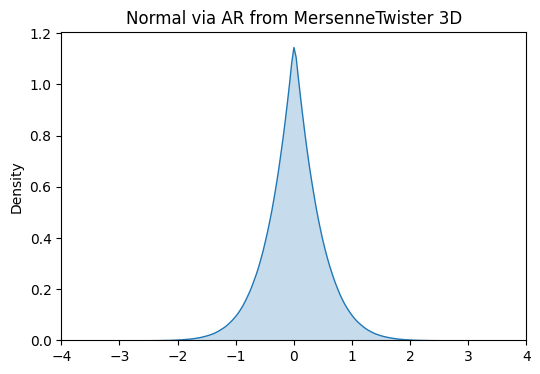

In [2]:
a = NDAR.NormalDistributionWithAcceptanceRejectionExperiment()
a.testARWithMersenneTwister3D()

Time AR from MersenneTwister 2D.....: " 75.006 " sec.


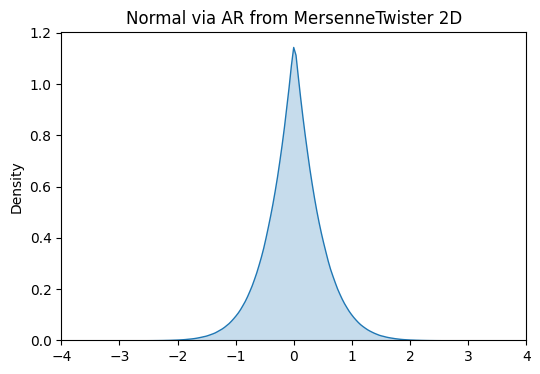

In [2]:
a = NDAR.NormalDistributionWithAcceptanceRejectionExperiment()
a.testARWithMersenneTwister2D()

Time ICDF from MersenneTwister 1D...:" 679.608 " sec.


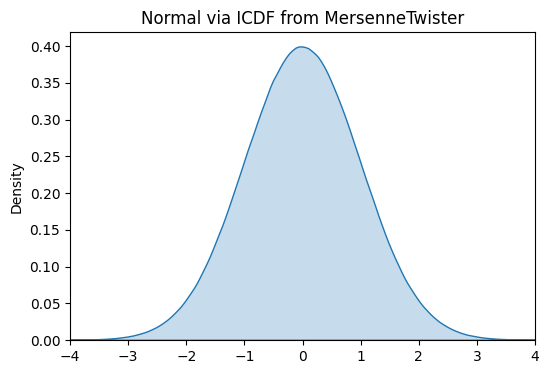

In [2]:
a = NDAR.NormalDistributionWithAcceptanceRejectionExperiment()
a.testICDFWithMersenneTwister()

### **DOUBLE EXPONENTIAL METHOD**
Alternatively, let X be a normal ditributed with density:
$$
f(x) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{1}{2}x^2\right), \quad -\infty < x < \infty
$$

Then we may sample a double exponential distributed random variable $Y$ with density:
$$
g(x) = \frac{1}{2} \exp(-|x|), \quad -\infty < x < \infty
$$

with the acceptance-rejection criteria: $u \leq \frac{f(x)}{C g(x)} = \exp\left(-\frac{1}{2}(|x| - 1)^2\right) \leq 1,\quad \text{with} \quad C = \sqrt{\frac{2e}{\pi}}$

<p align='center'>
<img src="image-27.png" alt="Acceptance-Rejection Method for Normal Distribution" width="500"/>
</p>

> Flip the Y to the positve side to the negative and I create a double eponential and I'm sampling then the double exponential distributed random variable $Y$.

So, we need to demonstrate that the double exponential distribution is a good candidate for the acceptance-rejection method to sample from the normal distribution.

We generate the G-distributed random variable $Y$ from the uniform random variable $V$ using the ICDF method:  
The distribution function of $Y$ is

$$
G(x) = \int_{-\infty}^{x} \frac{1}{2} \exp(-|\xi|)\, d\xi = 
\begin{cases}
\frac{1}{2} \exp(x), & x < 0 \\
\frac{1}{2} - \frac{1}{2}(\exp(-x) - 1), & x > 0
\end{cases}
= \frac{1}{2} - \operatorname{sign}(x) \cdot \frac{1}{2} \left( \exp(-|x|) - 1 \right)
$$

where:
- $g(\xi) = \frac{1}{2} \exp(-|\xi|) \to \quad \text{density of the double exponential distribution}$

Inverting: (`Don't forget to proove`)
$$
V = \frac{1}{2} \left(1 - \operatorname{sign}(Y) \left( \exp(-|Y|) - 1 \right)\right)
$$

gives:
$$
Y = -\operatorname{sign}(Y) \ln\left(1 - \operatorname{sign}(Y)(2V - 1)\right)
$$

and with $Y \geq 0 \Leftrightarrow G(Y) \geq \frac{1}{2} \Leftrightarrow V \geq \frac{1}{2} \Leftrightarrow 2V - 1 \geq 0$,  i.e., $\operatorname{sign}(Y) = \operatorname{sign}(2V - 1)$, we obtain:

$$
Y = -\operatorname{sign}(2V - 1) \ln\left(1 - |2V - 1|\right)
$$

<p align='center'>
<img src="image-28.png" alt="Acceptance-Rejection Method for Normal Distribution" width="300"/>
</p>
